In [161]:
# Spam SMS & Email Text Classifier

# Objective:
# Classify text messages as either SPAM or HAM (normal message).

In [162]:
import pandas as pd

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep="\t", header=None, names=["label", "message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [163]:
print("Dataset shape:", df.shape)
print("\nLabel counts:")
print(df["label"].value_counts())

Dataset shape: (5572, 2)

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64


In [164]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Missing values:
label      0
message    0
dtype: int64

Duplicate rows:
403


In [165]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


In [166]:
print(df["label"].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


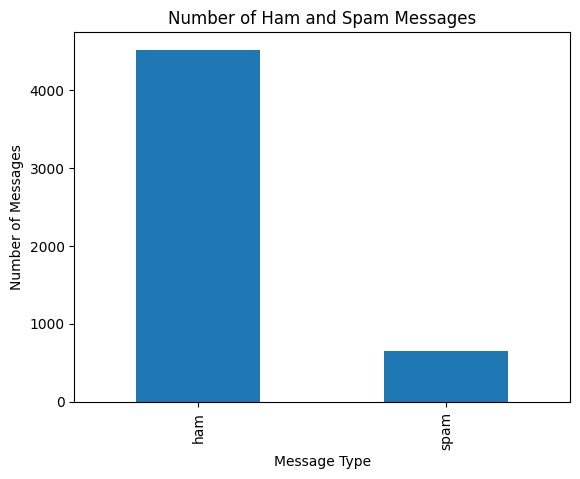

In [167]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Number of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

In [168]:
print("Example HAM message:")
print(df[df["label"] == "ham"]["message"].iloc[0])

print("\nExample SPAM message:")
print(df[df["label"] == "spam"]["message"].iloc[0])

Example HAM message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Example SPAM message:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


In [169]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X = vectorizer.fit_transform(df["message"])

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (5169, 8444)


In [170]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Input and output
X_text = df["message"]
y = df["label"]

# Split into training and testing data
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train_text))
print("Testing messages:", len(X_test_text))

Training messages: 4135
Testing messages: 1034


In [171]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)

Training TF-IDF shape: (4135, 7414)
Testing TF-IDF shape: (1034, 7414)


In [172]:
from sklearn.naive_bayes import MultinomialNB

# Create the model
model = MultinomialNB()

# Train the model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [173]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [174]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9671179883945842

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.96      1034



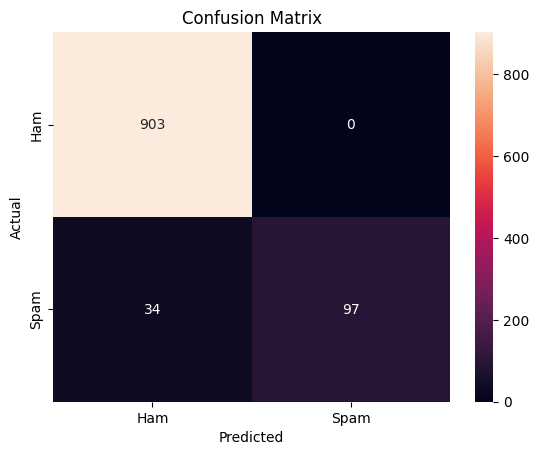

In [175]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [176]:
def predict_message(message):
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]

    return prediction.upper()

In [177]:
print(predict_message("Congratulations! You have won a free prize."))
print(predict_message("Hey, are we meeting at 5 pm today?"))

SPAM
HAM


In [178]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [179]:
y_pred_lr = logistic_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9564796905222437

Classification Report:
              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       903
        spam       0.98      0.67      0.80       131

    accuracy                           0.96      1034
   macro avg       0.97      0.83      0.89      1034
weighted avg       0.96      0.96      0.95      1034



In [180]:
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [0.9671, 0.9565],
    "Spam Precision": [1.00, 0.98],
    "Spam Recall": [0.74, 0.67],
    "Spam F1-Score": [0.85, 0.80]
})

comparison.style.hide(axis="index").format({
    "Accuracy": "{:.2%}",
    "Spam Precision": "{:.2%}",
    "Spam Recall": "{:.2%}",
    "Spam F1-Score": "{:.2%}"
})

Model,Accuracy,Spam Precision,Spam Recall,Spam F1-Score
Naive Bayes,96.71%,100.00%,74.00%,85.00%
Logistic Regression,95.65%,98.00%,67.00%,80.00%


In [181]:
test_messages = [
    "You have won a free lottery ticket! Claim your prize now.",
    "Can you send me the notes from today's class?",
    "URGENT! Your account has been selected for a cash reward.",
    "I'll meet you near the library at 4 pm.",
    "Congratulations! You are eligible for a special offer."
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_message(message))
    print()

Message: You have won a free lottery ticket! Claim your prize now.
Prediction: SPAM

Message: Can you send me the notes from today's class?
Prediction: HAM

Message: URGENT! Your account has been selected for a cash reward.
Prediction: SPAM

Message: I'll meet you near the library at 4 pm.
Prediction: HAM

Message: Congratulations! You are eligible for a special offer.
Prediction: HAM

